# 06 - The Closed Days Enter the Model

Notebook 05 ended with a ranked list of failure modes. The first item was by far
the largest: **the model cannot see the closed days around it.** A day after a
closed day scored 0.187 and a day before one 0.171, against 0.123 for a normal
day, and together those rows carried 57 percent of the squared error. The second
item was the feasts that move with Easter.

This notebook builds both and measures them. The bar is the same as for every
change in this project: four windows, three seeds, and the new features have to
win on every window, not only on average. Notebook 03 is the warning that makes
the measuring necessary. There we built two features for a pattern that was
perfectly clear in the raw data, and they did nothing.

The model we start from is one XGBoost per store segment, at **0.1451**.


In [1]:
import sys
from datetime import date
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
from src.data_loader import DataLoader
from src.features import (FeatureBuilder, build_closure_calendar, easter_sunday,
                          CLOSURE_COLUMNS, EASTER_COLUMNS)
from src.model import SalesModel, DEFAULT_PARAMS
from src.segments import StoreSegmenter
from src.validation import RollingOriginSplit
from src.metrics import rmspe

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
pl.Config.set_tbl_rows(20)

loader = DataLoader(PROJECT_ROOT / "data")
df = loader.load()
calendar = loader.load(drop_closed=False)
folds = list(RollingOriginSplit(n_splits=4).split(df))
print("Open days:  ", f"{df.height:,}")
print("All days:   ", f"{calendar.height:,}   (the closed days are the difference)")


Open days:   844,392
All days:    1,017,209   (the closed days are the difference)


## The closed-day family

Why does the model need help here at all? Because our training data holds open
days only. RMSPE cannot score a day with no sales, so the closed days were
dropped at the very start, and with them everything they could tell us. The
model knows that today is a holiday, but not that **tomorrow** is one - and the
day before a closed day is exactly when people buy for two days.

`build_closure_calendar` in `src/features.py` reads the calendar again, with
the closed days kept, and writes six columns for every store and day:

| Column | What it says |
|---|---|
| `open_yesterday`, `open_tomorrow` | was the shop open the day before, will it be open the day after |
| `closed_days_last_7`, `closed_days_next_7` | how many of the last and the next seven days the shop is closed |
| `days_since_last_holiday`, `days_to_next_holiday` | the distance to the closest state holiday of that store, cut at 10 |

None of this is learned from the sales. A shop plans its opening days and the
state publishes its holidays long in advance, and the competition test set
gives both (`Open` and `StateHoliday`) for the whole forecast period. So every
column is known six weeks ahead, which is what our task allows. The only
exception is the last day of the calendar, which has no tomorrow; it gets `-1`.

A day with no row at all counts as closed. That is what a missing row means
here: the shop was not trading. This matters for the 180 renovated stores,
whose missing months would otherwise look like ordinary days.


In [2]:
closure = build_closure_calendar(calendar)
print(closure.columns)
print(f"{closure.height:,} rows, one per store and day")


['Store', 'Date', 'open_yesterday', 'open_tomorrow', 'closed_days_next_7', 'closed_days_last_7', 'days_to_next_holiday', 'days_since_last_holiday']
1,017,209 rows, one per store and day


In [3]:
def show_days(store, first, last):
    """Print the closure columns of one store over a few days."""
    part = closure.filter((pl.col("Store") == store)
                          & (pl.col("Date") >= first) & (pl.col("Date") <= last))
    weekday = pl.col("Date").dt.strftime("%a").alias("day")
    with pl.Config(tbl_cols=12, tbl_width_chars=200):
        print(part.with_columns(weekday).select(["Date", "day"] + CLOSURE_COLUMNS))


print("Easter 2015. Good Friday (03 Apr) and Easter Monday (06 Apr) are closed,")
print("so the Saturday between them is the only open day in a four day block.")
show_days(1, date(2015, 4, 1), date(2015, 4, 7))


Easter 2015. Good Friday (03 Apr) and Easter Monday (06 Apr) are closed,
so the Saturday between them is the only open day in a four day block.
shape: (7, 8)
┌────────────┬─────┬────────────────┬───────────────┬────────────────────┬────────────────────┬──────────────────────┬─────────────────────────┐
│ Date       ┆ day ┆ open_yesterday ┆ open_tomorrow ┆ closed_days_next_7 ┆ closed_days_last_7 ┆ days_to_next_holiday ┆ days_since_last_holiday │
│ ---        ┆ --- ┆ ---            ┆ ---           ┆ ---                ┆ ---                ┆ ---                  ┆ ---                     │
│ date       ┆ str ┆ i64            ┆ i64           ┆ i64                ┆ i64                ┆ i64                  ┆ i64                     │
╞════════════╪═════╪════════════════╪═══════════════╪════════════════════╪════════════════════╪══════════════════════╪═════════════════════════╡
│ 2015-04-01 ┆ Wed ┆ 1              ┆ 1             ┆ 3                  ┆ 1                  ┆ 2                    

In [4]:
print("A normal week, for comparison.")
show_days(1, date(2015, 6, 8), date(2015, 6, 13))


A normal week, for comparison.
shape: (6, 8)
┌────────────┬─────┬────────────────┬───────────────┬────────────────────┬────────────────────┬──────────────────────┬─────────────────────────┐
│ Date       ┆ day ┆ open_yesterday ┆ open_tomorrow ┆ closed_days_next_7 ┆ closed_days_last_7 ┆ days_to_next_holiday ┆ days_since_last_holiday │
│ ---        ┆ --- ┆ ---            ┆ ---           ┆ ---                ┆ ---                ┆ ---                  ┆ ---                     │
│ date       ┆ str ┆ i64            ┆ i64           ┆ i64                ┆ i64                ┆ i64                  ┆ i64                     │
╞════════════╪═════╪════════════════╪═══════════════╪════════════════════╪════════════════════╪══════════════════════╪═════════════════════════╡
│ 2015-06-08 ┆ Mon ┆ 0              ┆ 1             ┆ 1                  ┆ 2                  ┆ 10                   ┆ 4                       │
│ 2015-06-09 ┆ Tue ┆ 1              ┆ 1             ┆ 1                  ┆ 2         

The Easter table shows the family doing its work. Look at Saturday the 4th of
April, the day the base model predicted **28 percent too low**: the shop was
closed yesterday (`open_yesterday` 0), it will be closed tomorrow
(`open_tomorrow` 0), two of the next seven days are closed, and a holiday was
one day ago. Every reason for the stockpiling of that day is now a number the
model can see.

In the normal week the columns are quiet. The only closed day is Sunday, so
`closed_days_next_7` stays at 1 and the holiday distances just count. That
quietness is important: the columns only speak when something unusual is near,
so they do not repeat the weekday, which the model already has.


## The distance to Easter

The carnival days are a different problem, and no closed-day column can fix it,
because the shops stay open through carnival - the customers in the carnival
regions simply stop coming.

Rosenmontag is always 48 days before Easter Sunday, and Easter moves: in our
data it falls three weeks apart between the years. The model reads a date as a
month, a day and a week number, so the carnival of 2015 (February) and the
carnival it trained on (March 2014) do not line up in any column it has.

The fix is one small feature: `days_to_easter`, the signed distance between the
day and Easter Sunday of its year, cut at 60 days on both sides. Easter comes
from the standard Gregorian rule in `easter_sunday`, so no lookup table is
needed. On this axis Rosenmontag is **-48 in every year**, Good Friday is -2,
and Whit Monday is +50. Three years of training data suddenly agree about where
the feasts are.


In [5]:
for year in [2013, 2014, 2015]:
    easter = easter_sunday(year)
    print(f"{year}: Easter Sunday {easter}, Rosenmontag {easter - __import__('datetime').timedelta(days=48)}")

sample = FeatureBuilder(with_easter=True).fit(folds[-1].train).transform(
    df.filter(pl.col("Store") == 1))
print()
print(sample.filter(pl.col("Date").is_in([date(2013, 2, 11), date(2014, 3, 3),
                                          date(2015, 2, 16), date(2015, 4, 4)]))
      .select(["Date", "days_to_easter"]))


2013: Easter Sunday 2013-03-31, Rosenmontag 2013-02-11
2014: Easter Sunday 2014-04-20, Rosenmontag 2014-03-03
2015: Easter Sunday 2015-04-05, Rosenmontag 2015-02-16



shape: (4, 2)
┌────────────┬────────────────┐
│ Date       ┆ days_to_easter │
│ ---        ┆ ---            │
│ date       ┆ i32            │
╞════════════╪════════════════╡
│ 2013-02-11 ┆ -48            │
│ 2014-03-03 ┆ -48            │
│ 2015-02-16 ┆ -48            │
│ 2015-04-04 ┆ -1             │
└────────────┴────────────────┘


The check above is the whole idea in one table: three different calendar dates,
one value. Whatever the model learns about day -48 from 2013 and 2014, it can
now apply to 2015.


## The experiment

Five arms, so that we learn not only whether the family helps but which part of
it does the work:

- **base**: the model of notebook 04, unchanged.
- **closure family**: all six closed-day columns.
- **flags only**: just the four open/closed columns, without the holiday
  distances.
- **holiday distance only**: just the two holiday distances.
- **closure + easter**: the full family plus `days_to_easter`.

Everything else is held fixed: the same folds, the same three seeds, the same
segmenter, one model per segment. The closure calendar is built once outside
the loop, because it is reference data and identical for every fold.

A warning before running: this cell trains 60 sets of four models and takes
most of an hour.


In [6]:
SEGMENTS = [1, 2, 3, 4]
SEEDS = [42, 7, 2024]

FLAGS = ["open_yesterday", "open_tomorrow", "closed_days_next_7", "closed_days_last_7"]
HOLIDAY = ["days_to_next_holiday", "days_since_last_holiday"]

# Each arm says which of the new columns the model may use.
ARMS = {
    "base": ([], False),
    "closure family": (CLOSURE_COLUMNS, False),
    "flags only": (FLAGS, False),
    "holiday distance only": (HOLIDAY, False),
    "closure + easter": (CLOSURE_COLUMNS, True),
}


def fit_predict(keep, with_easter, seed, fold):
    """One model per segment, with the base features plus the columns in `keep`.

    The feature builder and the segmenter are fitted on the training rows of
    the fold, exactly as before. The closure calendar is passed in ready made:
    it is reference data, not something we learn, so building it once outside
    the loop changes nothing and saves a lot of time.
    """
    builder = FeatureBuilder(calendar=closure, with_easter=with_easter).fit(fold.train)
    features = [f for f in builder.feature_names_
                if f not in CLOSURE_COLUMNS or f in keep]
    segmenter = StoreSegmenter(n_segments=4).fit(fold.train)
    tr = segmenter.transform(builder.transform(fold.train))
    va = segmenter.transform(builder.transform(fold.valid))

    parts, models = [], {}
    for s in SEGMENTS:
        tr_s, va_s = tr.filter(pl.col("segment") == s), va.filter(pl.col("segment") == s)
        if va_s.height == 0:
            continue
        model = SalesModel(params=dict(DEFAULT_PARAMS, seed=seed)).fit(tr_s, features)
        models[s] = model
        parts.append(va_s.with_columns(pl.Series("prediction", model.predict(va_s))))
    return pl.concat(parts), models


In [7]:
# This cell trains 5 arms x 3 seeds x 4 windows, so 60 sets of four models.
# It takes most of an hour.
scores, kept, importances = {}, {}, {}
for name, (keep, with_easter) in ARMS.items():
    grid = np.zeros((len(SEEDS), len(folds)))
    for i, seed in enumerate(SEEDS):
        for j, fold in enumerate(folds):
            out, models = fit_predict(keep, with_easter, seed, fold)
            grid[i, j] = rmspe(out["Sales"], out["prediction"])
            # Keep the scored rows, to see where the gain landed.
            kept.setdefault(name, []).append(
                out.select(["Store", "Date", "Sales", "prediction"])
                .with_columns(pl.lit(fold.index).alias("fold"),
                              pl.lit(seed).alias("seed")))
            if seed == SEEDS[0] and fold.index == 4:
                importances[name] = models[2].importance()
    scores[name] = grid
    print(f"{name:<24} " + " ".join(f"{v:.4f}" for v in grid.mean(axis=0))
          + f"   mean={grid.mean():.4f}  seed spread={grid.mean(axis=1).std():.4f}")

kept = {name: pl.concat(parts) for name, parts in kept.items()}


base                     0.1759 0.1441 0.1260 0.1345   mean=0.1451  seed spread=0.0002


closure family           0.1708 0.1025 0.1002 0.1103   mean=0.1209  seed spread=0.0009


flags only               0.1713 0.1077 0.1025 0.1124   mean=0.1235  seed spread=0.0005


holiday distance only    0.1709 0.1045 0.1033 0.1139   mean=0.1232  seed spread=0.0003


closure + easter         0.1657 0.0998 0.0999 0.1102   mean=0.1189  seed spread=0.0007


In [8]:
summary = pl.DataFrame({
    "arm": list(scores),
    **{f"window {i + 1}": [scores[n].mean(axis=0)[i] for n in scores] for i in range(4)},
    "mean": [scores[n].mean() for n in scores],
    "seed spread": [scores[n].mean(axis=1).std() for n in scores],
}).with_columns(pl.selectors.float().round(4))
print(summary)

base = scores["base"].mean(axis=0)
print("\nAgainst the base. A negative number means the arm is better.")
for name, grid in scores.items():
    if name == "base":
        continue
    delta = grid.mean(axis=0) - base
    print(f"  {name:<24} " + " ".join(f"{v:+.4f}" for v in delta)
          + f"   mean {grid.mean() - base.mean():+.4f}   better on {int((delta < 0).sum())}/4")


shape: (5, 7)
┌───────────────────────┬──────────┬──────────┬──────────┬──────────┬────────┬─────────────┐
│ arm                   ┆ window 1 ┆ window 2 ┆ window 3 ┆ window 4 ┆ mean   ┆ seed spread │
│ ---                   ┆ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---    ┆ ---         │
│ str                   ┆ f64      ┆ f64      ┆ f64      ┆ f64      ┆ f64    ┆ f64         │
╞═══════════════════════╪══════════╪══════════╪══════════╪══════════╪════════╪═════════════╡
│ base                  ┆ 0.1759   ┆ 0.1441   ┆ 0.126    ┆ 0.1345   ┆ 0.1451 ┆ 0.0002      │
│ closure family        ┆ 0.1708   ┆ 0.1025   ┆ 0.1002   ┆ 0.1103   ┆ 0.1209 ┆ 0.0009      │
│ flags only            ┆ 0.1713   ┆ 0.1077   ┆ 0.1025   ┆ 0.1124   ┆ 0.1235 ┆ 0.0005      │
│ holiday distance only ┆ 0.1709   ┆ 0.1045   ┆ 0.1033   ┆ 0.1139   ┆ 0.1232 ┆ 0.0003      │
│ closure + easter      ┆ 0.1657   ┆ 0.0998   ┆ 0.0999   ┆ 0.1102   ┆ 0.1189 ┆ 0.0007      │
└───────────────────────┴──────────┴──────────┴─────────

**The closed-day family is the largest single improvement in this project.**
It moves the model from 0.1451 to **0.1209**, a gain of 0.0242 - five times
what the segmentation won in notebook 04 - and it wins on all four windows,
with a seed spread near 0.001. Notebook 05 predicted the size of this almost
exactly: the flagged rows scored 0.180 against 0.122 for the rest, so if the
family fixed them completely the mean had to land near 0.121. It landed at
0.1209.

The ablation tells a second story, and it is the same story notebook 05 told
about the tables: **the two halves of the family are substitutes, not
partners.** The flags alone reach 0.1235 and the holiday distances alone reach
0.1232 - each two-column or four-column half captures almost the whole effect
on its own, and together they add only a little over the better half. That is
because in Germany the unusual closed days mostly *are* the state holidays; the
two halves write the same fact in two languages. We keep all six columns, since
the full family is still the best arm and the columns are cheap, but nobody
should read six separate features into this. It is one signal.

The window that gains least from the family is the oldest one (0.1759 to
0.1708). That is expected: its great weakness was carnival, and carnival is not
a closed day.

**The Easter distance earns its place on top of the family.** The combined arm
is the best one, at **0.1189**, better than the family alone on all four
windows. Its extra gain of 0.0021 is small on average, but it is not spread
thinly: almost all of it sits on the two windows that contain a moving feast,
-0.0051 on the carnival window and -0.0027 on the Easter window, while the two
feast-free summer windows barely move. A feature should help exactly where its
mechanism says and nowhere else, and this one does.

The carnival window is also a fresh reminder of why we run three seeds. With
the first seed alone the Easter feature seemed to do nothing there, and the
other two seeds put the truth near -0.005. One seed would have thrown the
feature away.


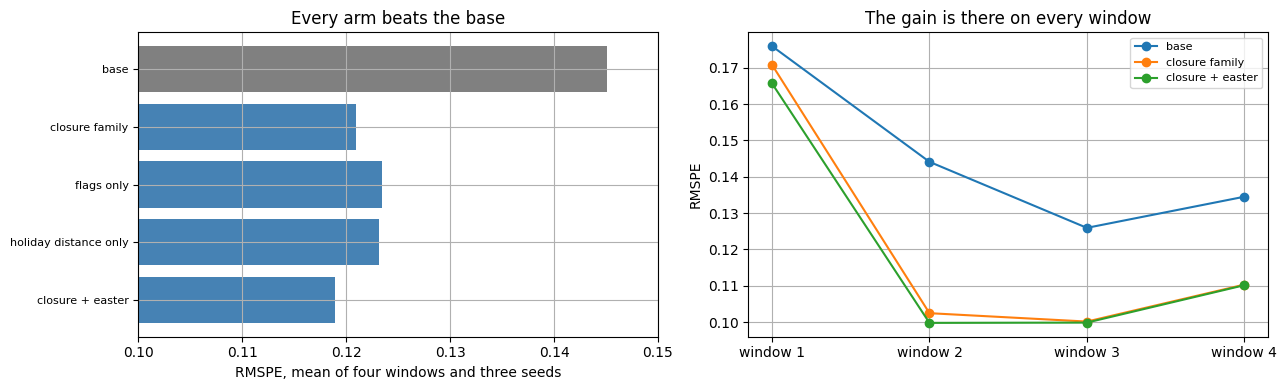

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

order = list(scores)
means = [scores[n].mean() for n in order]
colors = ["gray"] + ["steelblue"] * (len(order) - 1)
axes[0].barh(range(len(order)), means, color=colors)
axes[0].set_yticks(range(len(order)))
axes[0].set_yticklabels(order, fontsize=8)
axes[0].invert_yaxis()
axes[0].set_xlim(0.10, 0.15)
axes[0].set_xlabel("RMSPE, mean of four windows and three seeds")
axes[0].set_title("Every arm beats the base")

x = np.arange(1, 5)
for name in ["base", "closure family", "closure + easter"]:
    axes[1].plot(x, scores[name].mean(axis=0), marker="o", label=name)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"window {i}" for i in x])
axes[1].set_ylabel("RMSPE")
axes[1].set_title("The gain is there on every window")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


## Did the gain come from where we said it would?

A gain this large deserves suspicion. The claim from notebook 05 was specific -
the error sits on the days next to closures - so most of the fix must land on
those days. If the improvement were spread evenly over everything instead, our
explanation would be suspect, whatever the score says.

We kept the scored rows of every arm, so we can check.


In [10]:
neighbours = calendar.sort(["Store", "Date"]).with_columns(
    pl.col("Open").shift(1).over("Store").alias("open_yesterday"),
    pl.col("Open").shift(-1).over("Store").alias("open_tomorrow"),
).select(["Store", "Date", "open_yesterday", "open_tomorrow"])


def by_group(name):
    """RMSPE of one arm split by the closed days, averaged over the seeds."""
    per_seed = (kept[name].join(neighbours, on=["Store", "Date"], how="left")
                .filter(pl.col("Sales") != 0)
                .with_columns(
                    pl.when(pl.col("open_yesterday") == 0).then(pl.lit("after a closed day"))
                    .when(pl.col("open_tomorrow") == 0).then(pl.lit("before a closed day"))
                    .otherwise(pl.lit("a normal day")).alias("closure"),
                    (((pl.col("Sales") - pl.col("prediction")) / pl.col("Sales")) ** 2).alias("sq"))
                .group_by(["closure", "seed"])
                .agg(pl.col("sq").mean().sqrt().alias("_r"), pl.len().alias("rows")))
    return (per_seed.group_by("closure")
            .agg(pl.col("_r").mean().round(4).alias(name),
                 pl.col("rows").mean().cast(pl.Int64).alias("rows")))


table = by_group("base").join(
    by_group("closure family").drop("rows"), on="closure")
print(table.with_columns(
    (pl.col("closure family") - pl.col("base")).round(4).alias("change")).sort("rows"))


shape: (3, 5)
┌─────────────────────┬────────┬───────┬────────────────┬─────────┐
│ closure             ┆ base   ┆ rows  ┆ closure family ┆ change  │
│ ---                 ┆ ---    ┆ ---   ┆ ---            ┆ ---     │
│ str                 ┆ f64    ┆ i64   ┆ f64            ┆ f64     │
╞═════════════════════╪════════╪═══════╪════════════════╪═════════╡
│ before a closed day ┆ 0.1709 ┆ 27837 ┆ 0.128          ┆ -0.0429 │
│ after a closed day  ┆ 0.1868 ┆ 30002 ┆ 0.1652         ┆ -0.0216 │
│ a normal day        ┆ 0.1233 ┆ 97134 ┆ 0.1089         ┆ -0.0144 │
└─────────────────────┴────────┴───────┴────────────────┴─────────┘


In [11]:
worst = (kept["base"].filter(pl.col("Sales") != 0)
         .with_columns((((pl.col("Sales") - pl.col("prediction")) / pl.col("Sales")) ** 2)
                       .alias("sq"))
         .group_by("Date").agg(pl.col("sq").sum().alias("total"))
         .sort("total", descending=True).head(8)["Date"].to_list())

rows = []
for name in ["base", "closure family", "closure + easter"]:
    part = (kept[name].filter(pl.col("Sales") != 0)
            .with_columns((((pl.col("Sales") - pl.col("prediction")) / pl.col("Sales")) ** 2)
                          .alias("sq")))
    per_day = (part.filter(pl.col("Date").is_in(worst))
               .group_by(["Date", "seed"]).agg(pl.col("sq").mean().sqrt().alias("_r"))
               .group_by("Date").agg(pl.col("_r").mean().round(3).alias(name)))
    rows.append(per_day)

worst_table = rows[0]
for other in rows[1:]:
    worst_table = worst_table.join(other, on="Date")
print("The eight days that cost the base model the most")
print(worst_table.sort("Date"))


The eight days that cost the base model the most
shape: (8, 4)
┌────────────┬───────┬────────────────┬──────────────────┐
│ Date       ┆ base  ┆ closure family ┆ closure + easter │
│ ---        ┆ ---   ┆ ---            ┆ ---              │
│ date       ┆ f64   ┆ f64            ┆ f64              │
╞════════════╪═══════╪════════════════╪══════════════════╡
│ 2015-02-16 ┆ 0.661 ┆ 0.658          ┆ 0.622            │
│ 2015-02-17 ┆ 0.324 ┆ 0.313          ┆ 0.293            │
│ 2015-02-21 ┆ 0.319 ┆ 0.252          ┆ 0.256            │
│ 2015-04-01 ┆ 0.227 ┆ 0.15           ┆ 0.157            │
│ 2015-04-02 ┆ 0.219 ┆ 0.142          ┆ 0.141            │
│ 2015-04-04 ┆ 0.301 ┆ 0.142          ┆ 0.145            │
│ 2015-05-13 ┆ 0.238 ┆ 0.107          ┆ 0.102            │
│ 2015-07-04 ┆ 0.35  ┆ 0.164          ┆ 0.162            │
└────────────┴───────┴────────────────┴──────────────────┘


The gain is concentrated where the diagnosis pointed, but it is not only there.

The days before a closed day improve most, 0.171 to 0.128, and the days after
one next, 0.187 to 0.165. A normal day improves less, 0.123 to 0.109. The
order is the one the diagnosis asked for. Honesty needs the third number too:
the normal days do move, more than the story "only the closure days were
broken" would predict. Part of that is the holiday distances reaching two or
three days out, and part is simply that a model which no longer struggles with
the closure days spends its trees better everywhere.

The worst days of notebook 05 fall one by one. The Saturday of Easter drops
from 0.301 to 0.142 and the day before Ascension Day from 0.238 to 0.107 -
ordinary numbers now. The 4th of July, the day notebook 05 could not explain,
falls from 0.350 to 0.164: the closure columns reached it after all, even
though we never learned what made it special.

The carnival days are the stubborn ones. The closure family barely touches
them - the shops were open - and the Easter distance improves them, 0.658 to
0.622 on Rosenmontag, without fixing them. That fits what we know. The
carnival dip is regional, only the stores in the carnival regions fall, and
the model has no region column, so `days_to_easter` can learn the average dip
but not who dips. Rosenmontag stays the worst day of the validation set - now
for a reason we can name.


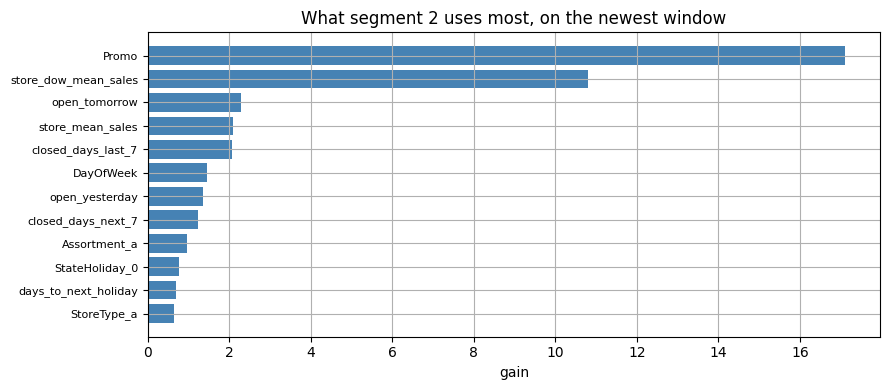

shape: (12, 2)
┌──────────────────────┬───────────┐
│ feature              ┆ gain      │
│ ---                  ┆ ---       │
│ str                  ┆ f64       │
╞══════════════════════╪═══════════╡
│ Promo                ┆ 17.107027 │
│ store_dow_mean_sales ┆ 10.795129 │
│ open_tomorrow        ┆ 2.280576  │
│ store_mean_sales     ┆ 2.096225  │
│ closed_days_last_7   ┆ 2.06226   │
│ DayOfWeek            ┆ 1.44723   │
│ open_yesterday       ┆ 1.362097  │
│ closed_days_next_7   ┆ 1.240805  │
│ Assortment_a         ┆ 0.951698  │
│ StateHoliday_0       ┆ 0.754154  │
│ days_to_next_holiday ┆ 0.681546  │
│ StoreType_a          ┆ 0.632264  │
└──────────────────────┴───────────┘


In [12]:
best = importances["closure + easter"].head(12)
plt.barh(range(best.height), best["gain"].to_numpy(), color="steelblue")
plt.yticks(range(best.height), best["feature"].to_list(), fontsize=8)
plt.gca().invert_yaxis()
plt.xlabel("gain")
plt.title("What segment 2 uses most, on the newest window")
plt.tight_layout()
plt.show()

print(best)


The model agrees with the ablation. The closure columns enter the importance
list at the top, next to the store statistics that carried the model so far.


## Key findings

1. **The closed-day family is adopted.** 0.1451 to **0.1209**, better on all
   four windows, twenty times the noise. It is the largest single gain in the
   project, ahead of the log transform (0.008) and the segmentation (0.005).
2. **The family is one signal, not six.** The open/closed flags alone give
   0.1235 and the holiday distances alone 0.1232. The halves are substitutes,
   because the unusual closures mostly are the holidays.
3. **The gain lands mostly where notebook 05 said the error was.** Days next
   to closures improve most and the old worst days fall to ordinary levels;
   normal days improve too, but by less. The diagnosis and the fix agree in
   their order, not only in their sum.
4. **`days_to_easter` is adopted.** 0.1189 against 0.1209 for the family
   alone, better on all four windows. The mean gain sits at our noise line,
   but it is concentrated on the carnival and the Easter windows (-0.0051 and
   -0.0027), exactly where the feature aims, and the feast-free windows are
   unchanged.
5. **Rosenmontag stays hard.** The Easter distance improves the carnival days
   but cannot fix them, because the dip is regional and the model has no
   region column. And the 4th of July, unexplained in notebook 05, was fixed
   by the closure family (0.350 to 0.164) without ever being explained.

One caution carries over from notebook 05. All four windows lie between
February and July, so the family is tested against Easter-season closures and
one carnival, not against December. The mechanism is general - a closed day is
a closed day - but the size of the gain in other seasons is not measured.

### What this means for the plan

Items 1 and 2 of the ranked list are done. The list continues with the days
since a renovated store came back, and a better day-of-month feature. After
that comes the tuning (step 8) and the calibration (step 9), both against a
much stronger model than they would have met a week ago.
